In [2]:
!pip install keras-tuner

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.1/176.1 KB 3.4 MB/s eta 0:00:00m eta 0:00:01


In [12]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import sklearn.model_selection as sm
from sklearn.preprocessing import MinMaxScaler
from tensorflow import keras as ks
from keras.callbacks import EarlyStopping
from keras.callbacks import ModelCheckpoint
import matplotlib as mpl
import matplotlib.pyplot as plt
import tensorflow as tf
import functions as fns
from ann_input import *
import math
pi=math.pi


In [7]:
npk=np.loadtxt(npk_p,usecols=(2,3,4,5,6,7))
k = np.loadtxt(k_p)
nbins = np.loadtxt(n_p)
params=np.loadtxt(path+'params_LH.txt')

#transforming pk to dpk
dpk=np.empty(np.shape(npk))
for i in range(len(npk)):
    for j in range(len(npk[0])):
        dpk[i,j]=((k[j]**3)*npk[i,j])/(2*pi**2)
with open(path+'cii_dpk','w+') as fn:
    np.savetxt(fn,dpk)


#preprocessing dpk for model
pk=np.log(dpk)/10

#preprocessing parameters for model
par=np.loadtxt('/media/sohini/Drive D/github_codes/CII_EMU_local/data/params_LH.txt')
mh=np.mean(par[:,0])

ms=np.std(par[:,0])

# In[16]:
def tr(p):
    y=((p-[mh,0])/[ms,1])/4
    return y

def inv_tr(p):
    x=4*np.multiply([ms,1],p)+[mh,0]
    return x
params=tr(par)

with open(path+'params_t','w+') as fn:
    np.savetxt(fn,params)

In [40]:
d=np.loadtxt(path+'cii_dpk')

In [24]:
#second transform
pk=np.log(pk)/10

In [25]:
#splitting data set into training set and test set
params_train,params_test,pk_train,pk_test = sm.train_test_split(params,pk, test_size=0.1, random_state=10,shuffle=True)
pk_fn = open('pk_test', 'w+')
params_fn = open('params_test', 'w+')

np.savetxt(pk_fn, pk_test)
np.savetxt(params_fn, params_test)

pk_fn.close()
params_fn.close()


In [28]:
#building and training the model
pred=fns.build_model(params_train,pk_train,params_test,pk_test,epochs,batch,val_frac,thres_acc,layers,neurons,dropout,dropout_rate,learning_rate,activation)



Epoch 1: loss improved from inf to 0.00105, saving model to cii_bestmodel


2023-06-27 18:13:43.866592: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'inputs' with dtype float and shape [?,144]
	 [[{{node inputs}}]]
2023-06-27 18:13:44.000586: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'inputs' with dtype float and shape [?,144]
	 [[{{node inputs}}]]
2023-06-27 18:13:45.030122: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'inputs' with dtype float and shape [?,144]
	 [[{{node inputs}}]]
2023-06-27 18:13

INFO:tensorflow:Assets written to: cii_bestmodel/assets


INFO:tensorflow:Assets written to: cii_bestmodel/assets



Epoch 2: loss improved from 0.00105 to 0.00026, saving model to cii_bestmodel


...


Epoch 38: loss did not improve from 0.00002

Epoch 39: loss did not improve from 0.00002

Epoch 40: loss did not improve from 0.00002

Epoch 41: loss did not improve from 0.00002

Epoch 42: loss improved from 0.00002 to 0.00002, saving model to cii_bestmodel


2023-06-27 18:16:29.855611: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'inputs' with dtype float and shape [?,144]
	 [[{{node inputs}}]]
2023-06-27 18:16:30.010162: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'inputs' with dtype float and shape [?,144]
	 [[{{node inputs}}]]
2023-06-27 18:16:31.518418: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'inputs' with dtype float and shape [?,144]
	 [[{{node inputs}}]]
2023-06-27 18:16

INFO:tensorflow:Assets written to: cii_bestmodel/assets


INFO:tensorflow:Assets written to: cii_bestmodel/assets


Training Accuracy is:  0.19772436935454607 
 Testing accuracy is:  0.16187841538339853
Training loss is:  0.00039094929888960905 
 Testing loss is:  0.0002620461827973486
1/1 [==============================] - 0s 318ms/step


In [29]:
#inverse transforming
pk_test=np.exp(10*pk_test)
pred=np.exp(10*pred)

In [30]:
err=(pred-pk_test)/pk_test

print("Mean percentage error: ", 100*np.mean(err))

Mean percentage error:  -0.9413681735313149


In [33]:
#saving predictions to file
pred_fn=open('predictions','w+')
pred=np.log(pred)/10
pred=np.log(pred)/10
np.savetxt(pred_fn,pred)
pred_fn.close()

In [38]:
pred=np.exp(10*pred)
pk_test[0]

array([0.57790649, 0.74156636, 0.90660152, 1.07179412, 1.22900372,
       1.37432291])

In [39]:
pred[0]

array([      nan,       nan,       nan, 1.0593363, 1.2267224, 1.3658596],
      dtype=float32)

In [22]:
pwd

'/media/sohini/Drive D/github_codes/CII_EMU_local'

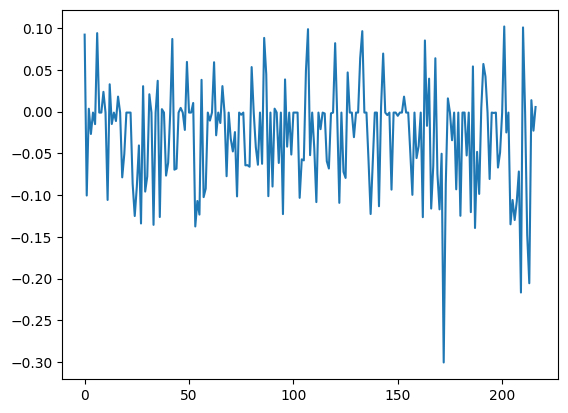

In [21]:
plt.plot(err[:,0])

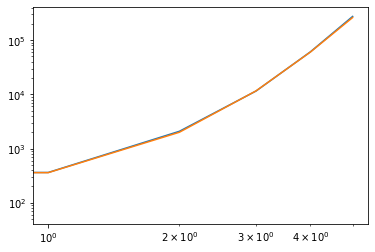

In [23]:
plt.xscale('log')
plt.yscale('log')
plt.plot(pk_test[145])
plt.plot(pred[145])

In [8]:
import warnings
warnings.filterwarnings('ignore')


import numpy as np
from cosmoHammer import MpiCosmoHammerSampler
from cosmoHammer import LikelihoodComputationChain
from sklearn.preprocessing import MinMaxScaler
from tensorflow import keras as ks
from cosmoHammer import CosmoHammerSampler
import matplotlib.pyplot as plt
import numpy as np
from tensorflow import keras as ks
#import MCMC_CosmoHammer as mcmc
import time
from cosmoHammer.util import Params
#peak, min., max., jump
from ann_input import *
# In[2]:
import math

pi=math.pi

import os

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'



In [9]:
prior= Params(('Mhmin',[5.0,0.0730406,18.0,0.00730406]),
              ('alpha', [1.58,1.58,1.58,0]))
err=np.loadtxt('data/cii_er')
par=np.loadtxt('data/params_LH.txt')
mh=np.mean(par[:,0])

ms=np.std(par[:,0])

# In[16]:
def tr(p):
    y=((p-[mh,0])/[ms,1])/4
    return y
def inv_tr(p):
    x=(y*4)/((p-[mh,0])/[ms,1])
    return x

In [26]:
class Core_Module(object):
    def __init__(self,model_name):
        self.model=ks.models.load_model(model_name)

    def __call__(self,ctx):
        par=ctx.getParams()

        ctx.add('params',par)

        params = np.array([i for i in par])
        params=np.reshape(tr(params),(1,2))
        model = ks.models.load_model('cii_model.h5')

        model_th=model.predict(params)
        model_th=np.exp(10*model_th)

        ctx.add("model_th",model_th)


    @staticmethod
    def setup():
        print("Core is done!")


# In[17]:


class Likelihood_Module(object):
    def __init__(self,data,nbins):
        self.data= data
        noise=(data/np.sqrt(nbins))
        try:
            eye = np.eye(len(data))
        except:
            eye=np.eye(1)
        if np.sum(nbins) != 0.:
            cov = abs(data ** 2) / nbins
            cov = cov + np.abs(noise)
            cov = eye * cov
            cov_inv = np.linalg.inv(cov)

        else:
            cov = np.abs(noise)
            cov = eye * cov
            cov_inv = np.linalg.inv(cov)

        self.div = 1.0
        self.cov = cov
        self.cov_inv = cov_inv
    # def computeLikelihood(self,ctx):
    #     model_th=ctx.get('model_th')
    #     #RAGHU# in our case model PS will be estimated using the emulator.
    #     # the likelihood is sum of the lot of normal distributions
    #     eps = self.cov
    #     denom = power(eps,2)
    #     lp = -0.5*sum(power((self.data - model_th),2)/denom + log(denom) + log(2*pi))
    #     return lp
    def computeLikelihood(self,ctx):
        model_th=ctx.get('model_th')
        diff=np.subtract(model_th,self.data).reshape(1,len(self.data))
        logl=-np.dot(diff,np.dot(self.cov_inv,diff.T))/2.
        return logl

    @staticmethod
    def setup():
        print("Likelihood setup done!")


# In[18]:


class RunMCMC:
    """ sampler & MPI sampler class """

    def __init__(self, prior, data, nbins, model, noise=0., div=1.0, like_func='n'):
        """
        :param data: load your data
        :param nbins: number of k-modes in powerspectrum OR
         number of triangle contributions in bispectrum (for covariance matrix)
        :param noise: system noise, e.g. SKA, MWA noise response (if any), default 0.0,
        :param div: likelihood normalization factor, default 1.0,
        :param like_func: choose between complex likelihood function (use 'c'), and normal function (use 'n')
        prefer complex likelihood for bispectrum
        """
        self.params=prior
        chain = LikelihoodComputationChain(min=self.params[:, 1], max=self.params[:, 2])
        chain.params = prior
        if like_func == 'n':
            chain.addLikelihoodModule(Likelihood_Module(data,nbins))
        else:
            chain.addLikelihoodModule(ComplexLikeModule(data, nbins, noise, div))
        self.chain = chain


    def load_model(self, load_model='cii_model.h5', name='pk'):

        """
        :param load_model: load your own model, (give the path)
        :param name: name for data, ('pk','bk')==>for powerspectrum, bispectrum
        :param norm: rescale used in the training
        """
        self.name = name
        self.chain.addCoreModule(Core_Module(load_model))
        self.chain.setup()


    def sampler(self, walker_ratio, burnin, samples, num, threads=-1):
        """
            :param walker_ratio:  the ratio of walkers and the count of sampled parameters
            :param burnin: burin iterations
            :param samples: no. of sample iterations
            :param num: number to put in output files e.g: string(name+num)=Pk_1,Bk_1
            :param threads: no. of cpu threads

            self.chain.setup()
            print("find best fit point")
            pso = MpiParticleSwarmOptimizer(self.chain, params[:, 1], params[:, 2])
            psoTrace = np.array([pso.gbest.position.copy() for _ in pso.sample()])
            params[:, 0] = pso.gbest.position
        """


        sampler = CosmoHammerSampler(
            params=self.params,
            likelihoodComputationChain=self.chain,
            filePrefix='%s' % self.name + '%d' % num,
            walkersRatio=walker_ratio,
            burninIterations=burnin,
            sampleIterations=samples, threadCount=threads)


        print("started sampling:")
        start = time.time()
        sampler.startSampling()
        end = time.time()
        tics = end - start
        print("The time taken %.2f sec. done!" % tics)
        print('Done!')




In [28]:
i=[202]
print("chosen values: ",params_test[i], "\n Chosen pk",pk_test[i])
#samples=input("enter number of samples: ")
samples=2000
samples=int(samples)

chosen values:  [[-0.11629599  0.395     ]] 
 Chosen pk [[1.10730575e+02 6.29420780e+02 3.64605121e+03 1.98428695e+04
  1.02405940e+05 4.58997481e+05]]


In [ ]:
n=np.loadtxt('data/nbins.txt')
for el in i:
    sampler=RunMCMC(prior=prior,data=pk_test[el],nbins=n,model='pk')
    sampler.load_model()
    sampler.sampler(walker_ratio=2,burnin=0.1*samples,samples=samples,num=el)

Core is done!
Likelihood setup done!
started sampling:


In [12]:
def inv_tr(p):
    x=4*np.multiply([ms,1],p)+[mh,0]
    return x

In [13]:
params_test=np.loadtxt('params_test')
x=inv_tr(params_test[202])

In [15]:
tr(x)

array([-0.11629599,  0.395     ])

In [25]:
p=np.loadtxt("data/params_LH.txt")

In [27]:
min(p[:,0]),max(p[:,0])

(0.0730406, 158.2789802)

In [3]:
!pip install tensorflow-gpu

Defaulting to user installation because normal site-packages is not writeable
  Using cached tensorflow-gpu-2.12.0.tar.gz (2.6 kB)
  Preparing metadata (setup.py) ... done
  error: subprocess-exited-with-error
  
  × python setup.py bdist_wheel did not run successfully.
  │ exit code: 1
  ╰─> [18 lines of output]
      Traceback (most recent call last):
        File "<string>", line 2, in <module>
        File "<pip-setuptools-caller>", line 34, in <module>
        File "/tmp/pip-install-is7hxm5t/tensorflow-gpu_67216a96f4f7464987a5e115c0f332a5/setup.py", line 37, in <module>
          raise Exception(TF_REMOVAL_WARNING)
      Exception:
      
      The "tensorflow-gpu" package has been removed!
      
      Please install "tensorflow" instead.
      
      Other than the name, the two packages have been identical
      since TensorFlow 2.1, or roughly since Sep 2019. For more
      information, see: pypi.org/project/tensorflow-gpu
      
      
      [end of output]
  
  note: This er

In [43]:
!pip install regressionmetrics

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.8/231.8 MB 2.8 MB/s eta 0:00:00m eta 0:00:010:00:01
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 440.7/440.7 kB 3.4 MB/s eta 0:00:00m eta 0:00:010:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 304.5/304.5 kB 5.2 MB/s eta 0:00:006.2 MB/s eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 5.0 MB/s eta 0:00:00m eta 0:00:010:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 4.3 MB/s eta 0:00:00m eta 0:00:010:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 3.1 MB/s eta 0:00:00m eta 0:00:010:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 6.2 MB/s eta 0:00:000:00:010:00:01:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.6/1

In [27]:
import numpy as np
from sklearn.metrics import *

def r2(y_true, y_pred):
    """
    R^2 (coefficient of determination) regression score function.
    Best possible score is 1.0, lower values are worse.
    Args:
        y_true ([np.array]): test samples
        y_pred ([np.array]): predicted samples
    Returns:
        [float]: R2
     """
    return r2_score(y_true, y_pred)

def rmse(y_true, y_pred):
    """
    Root Mean Square Error
    """
    return np.sqrt(mean_squared_error(y_true, y_pred))

def nrmse(y_true, y_pred):
    """
    Normalized Root Mean Square Error.
    Args:
        y_true ([np.array]): test samples
        y_pred ([np.array]): predicted samples
    Returns:
        [float]: normalized root mean square error
    """
    return rmse(y_true, y_pred) / (y_true.max() - y_true.min())

In [13]:
pk=np.loadtxt("data/pk_test")
pk=np.exp(10*pk)
pred=np.loadtxt("data/predictions")
print(pk[0],pred[0])

[0.71121 0.84845 0.98969 1.13791 1.28264 1.41985] [   1412.54467773    5315.66796875   21190.1015625    92754.59375
  407080.84375    1399157.        ]


In [14]:
pk=np.exp(10*pk)

In [15]:
pk

array([[1.22672096e+03, 4.83917727e+03, 1.98686820e+04, 8.74742725e+04,
        3.71907334e+05, 1.46666255e+06],
       [6.04075989e+02, 2.65553123e+03, 1.26827743e+04, 6.16112646e+04,
        2.82857920e+05, 1.17620063e+06],
       [1.25348768e+02, 6.93741907e+02, 4.04040414e+03, 2.19495079e+04,
        1.12803202e+05, 4.98221482e+05],
       ...,
       [1.23100365e+02, 6.85672426e+02, 3.99141067e+03, 2.16876879e+04,
        1.11413078e+05, 4.92229328e+05],
       [8.75578747e+01, 5.14245100e+02, 2.96460772e+03, 1.64322312e+04,
        8.75005187e+04, 3.97122470e+05],
       [4.11202212e+01, 2.32107355e+02, 1.33635361e+03, 7.43162632e+03,
        3.93597894e+04, 1.77282538e+05]])

In [20]:
r2(pk,pred)

0.9780879658572692

In [1]:
pwd

'/home/sohini/Documents/Codes/github_codes/CII_EMU_local'

In [5]:
import sklearn.model_selection as sm
import numpy as np

In [3]:
ls ../Cross_EMU_local/data/

cross_dpk         cross_nbins*                LH_sorted     pk_train
cross_dpk_pm      cross_pk*                   LH_updated*   predictions_k0
cross_dpk_sorted  cross_r*                    params_test   __pycache__/
cross_er          hyperparameter_sampling.py  params_train
cross_k*          LH_hyperparameters          pk_test


In [43]:
x=np.loadtxt('../Cross_EMU_local/data/params_train')
y=np.loadtxt('../Cross_EMU_local/data/pk_train')

In [44]:
X=np.log10(x)

In [45]:
y=np.log10(np.abs(y))

In [46]:
HP={'num_layers': 45,
'units': 28,
'activation': 'elu',
'dropout rate': 0.3675956905315022,
'dropout': True,
'lr': 0.0004910463854326264,
'loss': 'mse'
   }

In [47]:
layers=[28]*45

In [1]:
import numpy as np
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import KFold

layers=[144]*32
# Set up the MLPRegressor
mlp = MLPRegressor(hidden_layer_sizes=(layers), activation='elu', random_state=42, batch_size=4
                  , learning_rate='adaptive',learning_rate_init=HP['lr'],max_iter=1000)

# Set up k-fold cross-validation
k = 5  # Number of folds
kf = KFold(n_splits=k, shuffle=True, random_state=42)

# Perform cross-validation
fold = 1
for train_index, test_index in kf.split(X):
    print(f"Fold {fold}:")

    # Split data into training and testing sets
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # Fit the model to the training data
    mlp.fit(X_train, y_train)

    # Evaluate the model on the testing data
    score = mlp.score(X_test, y_test)
    print(f"Score: {score}\n")

    fold += 1

NameError: name 'HP' is not defined

In [22]:
xt=np.loadtxt("../Cross_EMU_local/data/params_test")

In [23]:
xt=np.log10(xt)

In [36]:
pred=[]
for el in xt:
    el=el.reshape(-1,3)
    pred.append(mlp.predict(el)[0])

In [26]:
pred[0]

array([[1.98982126, 2.45219337, 2.62670322, 2.14425597, 1.55097713,
        1.27182837]])

In [37]:
yt=np.loadtxt('../Cross_EMU_local/data/pk_test')

In [39]:
yt=np.log10(np.abs(yt))

In [35]:
np.shape(mlp.predict(el)[0])

(6,)

In [40]:
r2(yt,pred)

-0.016059126655963263

In [41]:
nrmse(yt,pred)

0.15064613601574187